<a href="https://colab.research.google.com/github/carn51/Assignment-1/blob/main/POTENTIAL_FINAL_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [34]:
df = pd.DataFrame(pd.read_csv('/content/StudentPerformanceFactors.csv'))
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23.0,84.0,Low,High,No,7,73,Low,Yes,0.0,Low,Medium,Public,Positive,3.0,No,High School,Near,Male,67.0
1,19.0,64.0,Low,Medium,No,8,59,Low,Yes,NaN,Medium,Medium,Public,Negative,4.0,No,College,Moderate,Female,61.0
2,24.0,98.0,Medium,Medium,Yes,7,91,Medium,Yes,2.0,Medium,Medium,Public,Neutral,4.0,No,Postgraduate,Near,Male,74.0
3,29.0,89.0,Low,Medium,Yes,8,98,Medium,Yes,1.0,Medium,Medium,Public,Negative,4.0,No,High School,Moderate,Male,71.0
4,19.0,92.0,Medium,Medium,Yes,6,65,Medium,Yes,3.0,Medium,High,Public,Neutral,4.0,No,College,Near,Female,70.0


In [35]:
drop_list = ['Distance_from_Home', 'Parental_Education_Level']
#df = df.drop(columns = drop_list)
df.shape

(6607, 20)

Missing data

In [36]:
df.isnull().sum()

,0
Hours_Studied,2
Attendance,2
Parental_Involvement,1
Access_to_Resources,2
Extracurricular_Activities,2
Sleep_Hours,0
Previous_Scores,0
Motivation_Level,1
Internet_Access,1
Tutoring_Sessions,1


Befrore dropping data examine (high num missing) variables' exam scores for skewness etc

<Axes: title={'center': 'Missing Teacher Quality Exam Score Distribution'}, xlabel='Scores', ylabel='Frequency'>

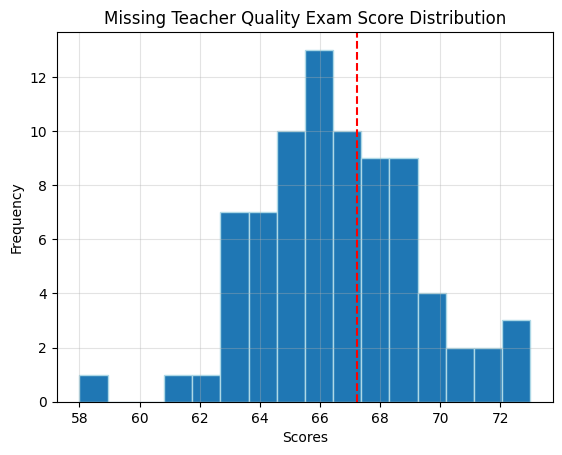

In [37]:
#filter out nulls for teacher quality
#plot shapes are indicative of not much skew
plt.title("Missing Teacher Quality Exam Score Distribution")
null_teacher_scores = df[df['Teacher_Quality'].isnull()]['Exam_Score']
plt.xlabel('Scores')
plt.ylabel("Frequency")
plt.grid(alpha = 0.35)

#overall mean from all other data
non_null_teacher_scores_mean = df[~df['Teacher_Quality'].isnull()]['Exam_Score'].mean()

plt.axvline(non_null_teacher_scores_mean, color = 'red', linestyle = '--')
null_teacher_scores.hist(bins = 16, edgecolor = 'lightblue')

Overlap missing

In [38]:
missing_overlap_pel = df['Parental_Education_Level'].isnull()
missing_overlap_dfh = df['Distance_from_Home'].isnull()

missing_overlap = pd.crosstab(missing_overlap_pel, missing_overlap_dfh)
print(missing_overlap)

Distance_from_Home        False  True 
Parental_Education_Level              
False                      6449     68
True                         90      0


Drop null rows

In [39]:
df = df.dropna()

EDA including category types and exploration

In [43]:
cats = df.select_dtypes(include = 'object').astype('category')
cats.columns

Index(['Parental_Involvement', 'Access_to_Resources',
       'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access',
       'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence',
       'Learning_Disabilities', 'Parental_Education_Level',
       'Distance_from_Home', 'Gender'],
      dtype='object')

Split

Preprocess